# Inference Quick Start

This notebook shows how to run Migas-1.5 on **your own data** end-to-end:

1. **Load time series data** — load values from a CSV file (columns: `t`, `y_t`, `split`).
2. **Prepare a text summary** — learn the two-part `FACTUAL SUMMARY` + `PREDICTIVE SIGNALS` format the model expects. A sample summary is provided so the notebook runs out of the box; an optional section shows how to auto-generate one with an LLM.
3. **Forecast** — compare Chronos-2 (text-free baseline) against Migas-1.5 (text-conditioned).
4. **Counterfactual exploration** — rewrite the predictive signals and watch the forecast shift, demonstrating the text-conditioned time series forecasting.

**Requirements:** Install the package from the repo root (`uv sync`). Section 3 (LLM summary generation) optionally requires an OpenAI or Anthropic API key.

**See also:** [Counterfactual Scenarios](migas-1.5-counterfactual-scenarios.ipynb) · [Batch Inference](migas-1.5-batch-inference.ipynb) · [Backtest and Metrics](migas-1.5-backtest-and-metrics.ipynb)

## User Configuration

**Edit the cell below before running anything else.** All parameters you are likely to
want to change are collected here — you should not need to touch anything else in the
notebook for a basic run.

| Parameter | What it controls | Typical values |
|-----------|-----------------|----------------|
| `DATA_PATH` | CSV with columns `t`, `y_t`, `split` (`"context"` / `"ground_truth"`) | Relative to this notebook |
| `SUMMARY_PATH` | Pre-computed summary text file | Relative to this notebook |
| `SERIES_NAME` | Human-readable name for the series (used in plot labels and LLM prompts) | Any descriptive string |
| `SEQ_LEN` | Steps of history fed to the model (context window) | shorter = clearer local trends |
| `PRED_LEN` | Number of steps to forecast | `8` – `64` |
| `LLM_PROVIDER` | LLM used to auto-generate the text summary in Section 3 | `"anthropic"` (recommended) or `"openai"` |
| `LLM_API_KEY` | API key for the LLM provider — **required only for Section 3** | Set via env var `ANTHROPIC_API_KEY` / `OPENAI_API_KEY` |
| `TEXT_SOURCE` | Where per-timestep text comes from: `"web_search"` (Claude searches the web) or `"dataframe"` (use `text` column from CSV) | `"web_search"` (default) |

**Also check:**
- **Section 2** — replace the loaded `summary` with one that matches your series and date window.
- **Section 5** — edit `bullish_predictive` / `bearish_predictive` to craft your own counterfactual narratives.

In [1]:
import os
from migaseval.notebook_helpers import find_repo_root, require_data

# ── USER CONFIGURATION — edit here, then run the notebook top-to-bottom ──────

_REPO_ROOT = find_repo_root()
_NOTEBOOKS = os.path.join(_REPO_ROOT, "notebooks")
DATA_PATH = require_data(
    os.path.join(_NOTEBOOKS, "data/timemmd_energy_sample.csv"),
    "Place your CSV in notebooks/data/ (see README for format)",
)  # <-- CHANGE ME: CSV with columns t, y_t, split
SUMMARY_PATH = require_data(
    os.path.join(_NOTEBOOKS, "data/timemmd_energy_sample_summary.txt"),
    "Place your summary text file in notebooks/data/ (see Section 3 to generate one)",
)  # <-- CHANGE ME: pre-computed summary text file
SERIES_NAME = (
    "US Natural Gas (Henry Hub)"  # <-- CHANGE ME: human-readable name for the series
)
SEQ_LEN = 64  # <-- CHANGE ME: context window in steps
PRED_LEN = 16  # <-- CHANGE ME: forecast horizon in steps
LLM_PROVIDER = "anthropic"  # <-- CHANGE ME: "anthropic" (recommended) | "openai"
LLM_API_KEY = os.getenv(
    {"anthropic": "ANTHROPIC_API_KEY", "openai": "OPENAI_API_KEY"}[LLM_PROVIDER]
)
# LLM_API_KEY is optional — only needed for Section 3 (LLM summary generation)
TEXT_SOURCE = "dataframe"  # <-- CHANGE ME: "web_search" (Claude finds news) | "dataframe" (use text column from CSV)


# ─────────────────────────────────────────────────────────────────────────────

In [2]:
import warnings

warnings.filterwarnings("ignore", message="IProgress not found")

from textwrap import dedent

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from migaseval import MigasPipeline
from migaseval.model.inference_utils import evaluate_chronos_quantiles
from migaseval.counterfactual_utils import (
    composite_trend_score,
    extract_factual,
    extract_predictive,
    linear_slope,
    splice_summary,
)
from migaseval.summary_utils import call_llm, generate_summary
from migaseval.plotting_utils import (
    COLORS,
    _draw_forecast_region,
    apply_migas_style,
    format_date_axis,
    plot_forecast_single,
)

apply_migas_style()

device = "cuda" if torch.cuda.is_available() else "cpu"
pipeline = MigasPipeline.from_pretrained(
    "Synthefy/migas-1.5", device=device, text_embedder_device=device
)
print(f"Using device: {device}")

Loading Chronos-2 on device: cpu
Initialized univariate model: chronos
Using device: cpu


## 1. Load Time Series Data

Below we load values from a CSV file. The CSV must have at least two columns:

| Column | Description |
|--------|-------------|
| `t` | Date string (`YYYY-MM-DD`) |
| `y_t` | Numeric value |

The last `SEQ_LEN + PRED_LEN` rows are taken: the first `SEQ_LEN` rows form the
**context window** fed to the model; the remaining `PRED_LEN` rows are held out as
**ground truth** so we can measure forecast accuracy.

You can swap `DATA_PATH` for any CSV that follows this format.

In [3]:
raw = pd.read_csv(DATA_PATH)
raw["t"] = pd.to_datetime(raw["t"]).dt.strftime("%Y-%m-%d")

# Take the last SEQ_LEN + PRED_LEN rows so the window is always exactly the right size
_cols = ["t", "y_t"] + (["text"] if "text" in raw.columns else [])
full = raw[_cols].iloc[-(SEQ_LEN + PRED_LEN) :].reset_index(drop=True)

# Context window fed to the model
series = full.iloc[:SEQ_LEN][_cols].copy().reset_index(drop=True)
if "text" not in series.columns:
    series["text"] = ""


# Ground truth for the forecast horizon
gt_vals = full.iloc[SEQ_LEN:]["y_t"].values.astype(np.float32)

print(
    f"Context window : {SEQ_LEN} steps  ({series['t'].iloc[0]} → {series['t'].iloc[-1]})"
)
print(
    f"Forecast window: {PRED_LEN} steps  ({full['t'].iloc[SEQ_LEN]} → {full['t'].iloc[-1]})"
)
print(f"Context value range : {series['y_t'].min():.4f} – {series['y_t'].max():.4f}")
series.tail()

Context window : 64 steps  (2019-01-27 → 2020-04-12)
Forecast window: 16 steps  (2020-04-19 → 2020-08-02)
Context value range : 2.0220 – 2.9830


,t,y_t,text
59,2020-03-15,2.468,Recent trends indicate sustained downward pres...
60,2020-03-22,2.343,Gasoline prices have exhibited a sustained dow...
61,2020-03-29,2.217,Gasoline prices continue to decline amid persi...
62,2020-04-05,2.103,Gasoline prices continue to decline amid persi...
63,2020-04-12,2.022,Gasoline prices continue to decline amid persi...


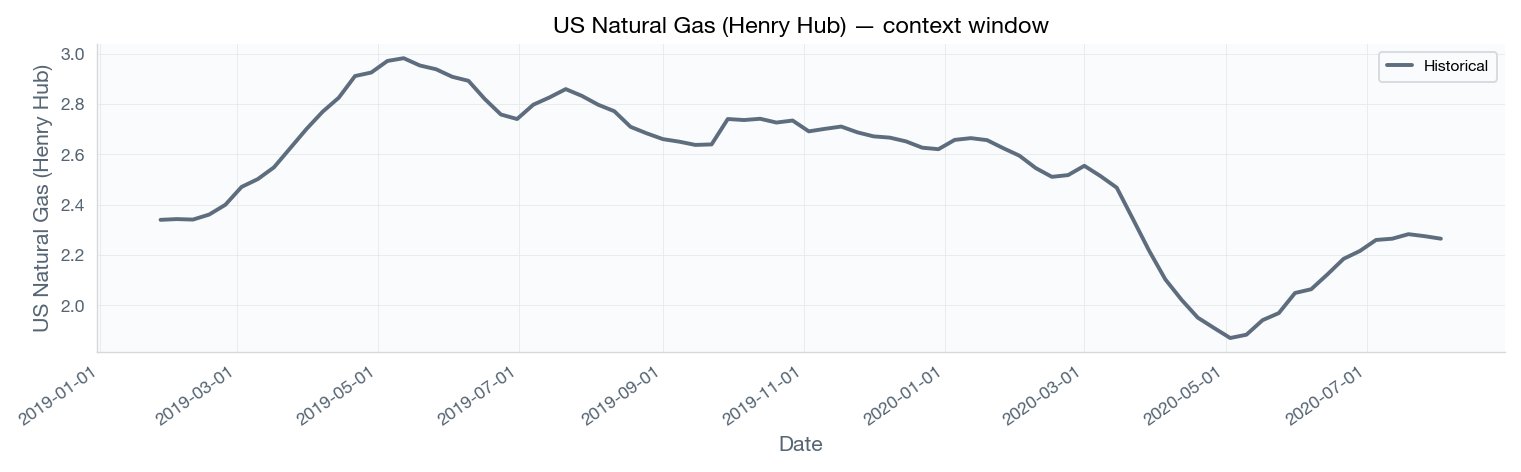

In [4]:
# Quick look at the context window before running the model
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(
    pd.to_datetime(full["t"].values),
    full["y_t"].values,
    color=COLORS["historical"],
    lw=2.0,
    solid_capstyle="round",
    label="Historical",
)
format_date_axis(ax)
ax.set_xlabel("Date", color="#566573")
ax.set_ylabel(SERIES_NAME, color="#566573")
ax.set_title(f"{SERIES_NAME} — context window")
ax.legend(fontsize=8, handlelength=1.6)
fig.tight_layout(pad=1.2)
plt.show()

## 2. Understanding the Summary Format

Migas-1.5 accepts a **text summary** alongside the time series. The summary must follow a two-part structure:

| Section | Purpose |
|---------|---------|
| `FACTUAL SUMMARY` | What already happened — observed trends, price action, key events, macro drivers |
| `PREDICTIVE SIGNALS` | Forward-looking interpretation — analyst outlook, catalysts, risks |

This is the format produced by Migas-1.5's internal `ContextSummarizer` (which calls an LLM over per-timestep text). The model was trained to condition on this structure, so deviating significantly from it will reduce text impact.

Below is a pre-computed summary for the energy series loaded above. **To generate a fresh one from real headlines, see Section 3.**

In [5]:
# Load pre-computed summary — illustrates the required format.
# Replace with a summary that matches your series and date window,  # <-- CHANGE ME
# or let Section 3 generate one automatically with an LLM.
with open(SUMMARY_PATH) as f:
    summary = [f.read().strip()]

news_digest = ""

print(summary[0])

**FACTUAL SUMMARY:**  
- From timesteps 1‑19 the series showed modest fluctuations around –0.3 to –0.2, reflecting a market still anchored by U.S. production strength, seasonal demand, and intermittent geopolitical shocks.  
- Beginning with timestep 20 the values accelerated downward, reaching –1.60 by timestep 32 as the COVID‑19 pandemic, an oil‑price war, and record U.S. output created a severe supply‑demand imbalance, driving gasoline prices to historic lows.  

**PREDICTIVE SIGNALS:**  
- The narrative repeatedly cites “inventory draw‑downs,” “economic reopening,” and “refinery utilization recovery” as the primary near‑term catalysts, suggesting prices will likely stabilize or modestly rebound once demand resurfaces and excess stock is absorbed.  
- Longer‑term signals point to a structural transition—rising alternative‑fuel adoption, continued U.S. export capacity, and persistent low‑demand scenarios—that will keep price volatility elevated and may establish a lower price floor e

## 3. (Optional) Generate a Summary with an LLM

A good summary requires context about the series over the full context window.

This section generates a `FACTUAL SUMMARY` + `PREDICTIVE SIGNALS` using an LLM.           
                                                                                          
The `TEXT_SOURCE` parameter (set above) controls where per-timestep text comes from:      
                                                                                          
- **`"web_search"`** (default) — Claude uses its built-in web search tool to autonomously 
  find news and market events for the exact date range, then summarizes them. Requires    
  `llm_provider="anthropic"`.                                                             
- **`"dataframe"`** — uses the `text` column from the loaded CSV directly. The LLM        
  summarizes the provided text instead of searching the web. This is useful when your     
  data already has per-timestep annotations (headlines, analyst notes, etc.). Works with  
  any provider.                                                                           


**Required environment variables:**
- `ANTHROPIC_API_KEY` or `OPENAI_API_KEY` — required to call the LLM.

If no LLM key is found the section is skipped and the pre-computed summary is kept.

In [6]:
# LLM_PROVIDER is set in the User Configuration cell at the top of the notebook.
LLM_BASE_URL = os.getenv("VLLM_BASE_URL")  # None → use provider default
LLM_MODEL = os.getenv("VLLM_MODEL")  # None → use provider default

In [ ]:
if not LLM_API_KEY:
    print("Skipping LLM summary generation — no LLM API key found.")
    print("Using the pre-computed summary.")
else:
    summary, news_digest = generate_summary(
        SERIES_NAME,
        series,
        PRED_LEN,
        llm_provider=LLM_PROVIDER,
        llm_api_key=LLM_API_KEY,
        llm_base_url=LLM_BASE_URL,
        llm_model=LLM_MODEL,
        return_news=True,
        text_source=TEXT_SOURCE,
        n_summaries=5,
    )
    if news_digest:
        print("\n" + "=" * 60)
        print("NEWS DIGEST (raw web search findings)")
        print("=" * 60)
        print(news_digest)

Using text from DataFrame for US Natural Gas (Henry Hub) (64/64 rows have text) …
Generating 9 summary(ies) …
  Generated summary 1/9
  Generated summary 2/9
  Generated summary 3/9
  Generated summary 4/9
  Generated summary 5/9
  Generated summary 6/9
  Generated summary 7/9
  Generated summary 8/9
  Generated summary 9/9

Generated 9 summary(ies):

**FACTUAL SUMMARY:**  
From January 2019 through April 2020, U.S. gasoline prices exhibited a dramatic 14-month contraction from $2.34 to $2.02 per gallon (−13.7%), punctuated by three distinct phases. January–March 2019 saw price stability ($2.34–$2.41) amid sustained U.S. shale production and global oversupply. April–October 2019 delivered a sharp rally to $2.97 (peak on April 7), driven by tightening refinery margins, geopolitical shocks (Saudi Aramco attack in September), and structural supply constraints. November 2019–April 2020 reversed sharply, with prices collapsing to $2.02 following the OPEC+ coordination breakdown, pandemic de

## 4. Forecast: Chronos-2 Baseline vs. Migas-1.5

We run two forecasts on the same numerical context:

- **Chronos-2** — Migas's own internal Chronos backbone, before text fusion.
- **Migas-1.5** — same Chronos base, fused with the text summary above.

Both share the **exact same normalization path and Chronos call** — so the gap
between the two lines is the pure text conditioning effect.

**If the pre-written summary doesn't match your actual data window**, text can
steer the forecast in the wrong direction (Migas MAPE > Chronos MAPE). Run
Section 3 to generate a window-aligned summary and close that gap.

In [24]:
context_vals = series["y_t"].values.astype(np.float32)
context_tensor = (
    torch.tensor(context_vals, dtype=torch.float32)
    .unsqueeze(0)
    .unsqueeze(-1)
    .to(device)  # (1, SEQ_LEN, 1)
)

# Migas-1.5 + its internal Chronos-2 baseline — same normalization path, one call
migas_fc, chronos_fc_raw = pipeline.predict_from_dataframe(
    series,
    pred_len=PRED_LEN,
    seq_len=SEQ_LEN,
    summaries=summary,
    return_univariate=True,
)
chronos_fc = chronos_fc_raw

# Chronos-2 uncertainty band (10th / 90th percentile) — standalone call for shading only
chronos_q = evaluate_chronos_quantiles(
    context_tensor,
    PRED_LEN,
    device=device,
    chronos_device=device,
    quantile_levels=[0.1, 0.9],
)
chronos_lo = chronos_q["0.1"][0]
chronos_hi = chronos_q["0.9"][0]

print(
    f"Chronos-2 forecast : {chronos_fc.shape}  range [{chronos_fc.min():.4f}, {chronos_fc.max():.4f}]"
    f"  (80% band: [{chronos_lo.min():.4f}, {chronos_hi.max():.4f}])"
)
print(
    f"Migas-1.5 forecast : {migas_fc.shape}  range [{migas_fc.min():.4f}, {migas_fc.max():.4f}]"
)
print(
    "Note: Chronos-2 line is Migas's own internal baseline. Gap = text conditioning effect."
)

Chronos-2 forecast : (16,)  range [1.8696, 1.9307]  (80% band: [1.1556, 2.5650])
Migas-1.5 forecast : (16,)  range [1.9501, 2.2612]
Note: Chronos-2 line is Migas's own internal baseline. Gap = text conditioning effect.


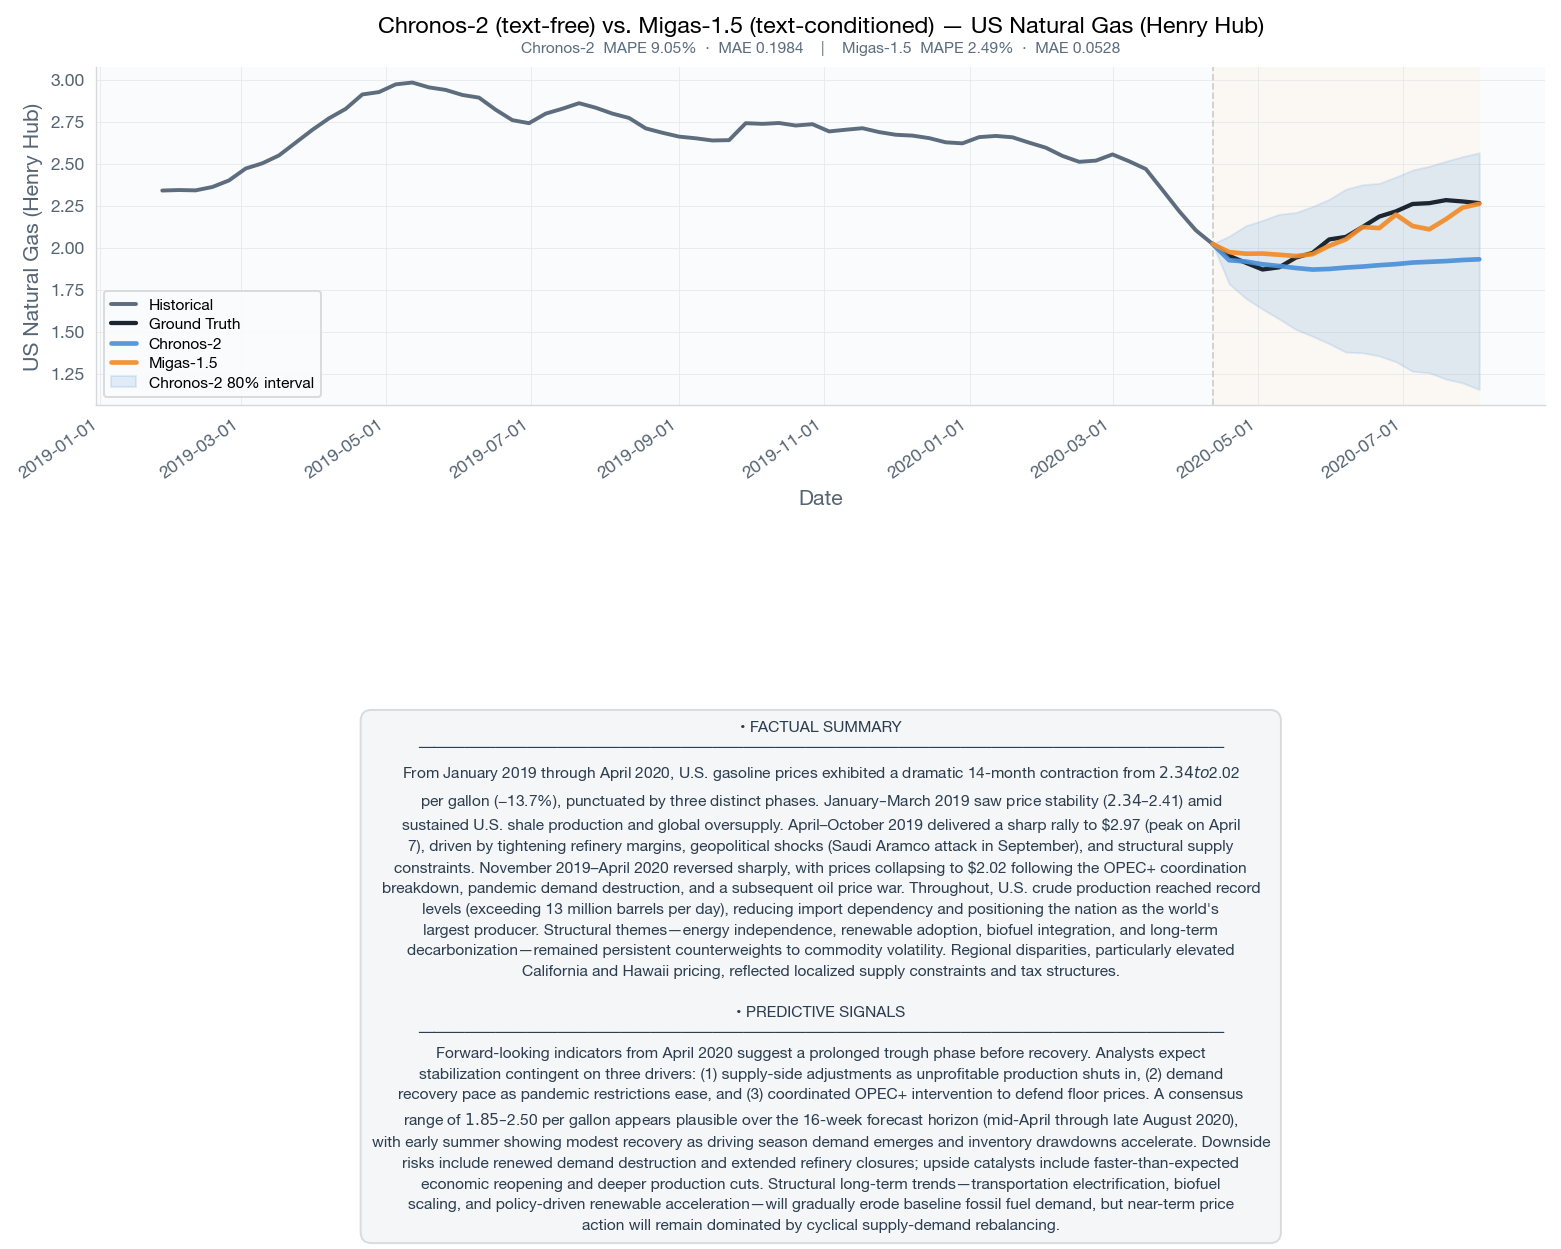

Chronos-2 slope  : +0.00162
Migas-1.5 slope  : +0.02105
Slope difference : +0.01943


In [25]:
t_ctx = pd.to_datetime(full["t"].values[:SEQ_LEN])
t_pred = pd.to_datetime(list(full["t"].values[SEQ_LEN - 1 :]))
last_val = float(context_vals[-1])

fig, ax = plot_forecast_single(
    context_vals,
    gt_vals,
    {"Chronos-2": chronos_fc, "Migas-1.5": migas_fc},
    SEQ_LEN,
    PRED_LEN,
    title=f"Chronos-2 (text-free) vs. Migas-1.5 (text-conditioned) — {SERIES_NAME}",
    figsize=(11, 4),
    show_metrics=True,
    text_summary=summary[0],
    timestamps=full["t"].values,
)
# Add Chronos-2 uncertainty band (10th–90th percentile)
ax.fill_between(
    t_pred,
    np.concatenate([[last_val], chronos_lo]),
    np.concatenate([[last_val], chronos_hi]),
    alpha=0.15,
    color=COLORS["Chronos-2"],
    label="Chronos-2 80% interval",
    zorder=2,
)
ax.legend(fontsize=8, handlelength=1.6, labelspacing=0.35, borderpad=0.45)
ax.set_ylabel(SERIES_NAME, color="#566573")
plt.show()

print(f"Chronos-2 slope  : {linear_slope(chronos_fc):+.5f}")
print(f"Migas-1.5 slope  : {linear_slope(migas_fc):+.5f}")
print(f"Slope difference : {linear_slope(migas_fc) - linear_slope(chronos_fc):+.5f}")

## 5. Counterfactual — Rewrite the Narrative

Here is the core idea behind Migas-1.5: **the numerical input is identical across all
runs below — only the text changes.**

We keep the **factual section** unchanged (what already happened doesn't change) and
replace only the **predictive signals** with a bullish or bearish outlook.
If the model truly integrates text with time series, the forecast should shift
in the direction of the new narrative.

Edit `bullish_predictive` / `bearish_predictive` below to craft your own counterfactual narratives and watch the forecast shift.


In [26]:
# extract_factual / extract_predictive handle list[str] natively.
# For display, show the first summary's sections.
_factual = extract_factual(summary)
_predictive = extract_predictive(summary)
print("Factual section (unchanged across all scenarios):\n")
print(_factual[0])
print("\nOriginal predictive section:\n")
print(_predictive[0])

Factual section (unchanged across all scenarios):

FACTUAL SUMMARY:**  
From January 2019 through April 2020, U.S. gasoline prices exhibited a dramatic 14-month contraction from $2.34 to $2.02 per gallon (−13.7%), punctuated by three distinct phases. January–March 2019 saw price stability ($2.34–$2.41) amid sustained U.S. shale production and global oversupply. April–October 2019 delivered a sharp rally to $2.97 (peak on April 7), driven by tightening refinery margins, geopolitical shocks (Saudi Aramco attack in September), and structural supply constraints. November 2019–April 2020 reversed sharply, with prices collapsing to $2.02 following the OPEC+ coordination breakdown, pandemic demand destruction, and a subsequent oil price war. Throughout, U.S. crude production reached record levels (exceeding 13 million barrels per day), reducing import dependency and positioning the nation as the world's largest producer. Structural themes—energy independence, renewable adoption, biofuel integ

In [27]:
# Counterfactual narratives — edit these to test different scenarios.  # <-- CHANGE ME
bullish_predictive = dedent("""
**PREDICTIVE SIGNALS:**  :
A sudden geopolitical escalation in major LNG export regions combined with unexpected
winter demand surge across North America and Europe creates immediate supply constraints.
Coupled with coordinated OPEC+ production cuts that restore crude oil prices and renewed
industrial activity post-pandemic, natural gas would experience sustained upward momentum,
reversing the deflationary trajectory and compressing the negative spread significantly.
""").strip()


bearish_predictive = dedent("""
**PREDICTIVE SIGNALS:**  :
- A prolonged economic recession, accelerated electrification of heating systems, and a glut
of domestic shale production coming online simultaneously would create a structural demand
collapse while supply remains abundant. The series would likely extend its downward
trajectory beyond timestep 32, with natural gas prices remaining anchored near or below
the pandemic-crisis lows as oversupply persists and storage facilities struggle to absorb
excess volumes.
""").strip()

bullish_summary = splice_summary(summary, bullish_predictive)
bearish_summary = splice_summary(summary, bearish_predictive)

In [28]:
bullish_fc = pipeline.predict_from_dataframe(
    series, pred_len=PRED_LEN, seq_len=SEQ_LEN, summaries=bullish_summary
)
bearish_fc = pipeline.predict_from_dataframe(
    series, pred_len=PRED_LEN, seq_len=SEQ_LEN, summaries=bearish_summary
)

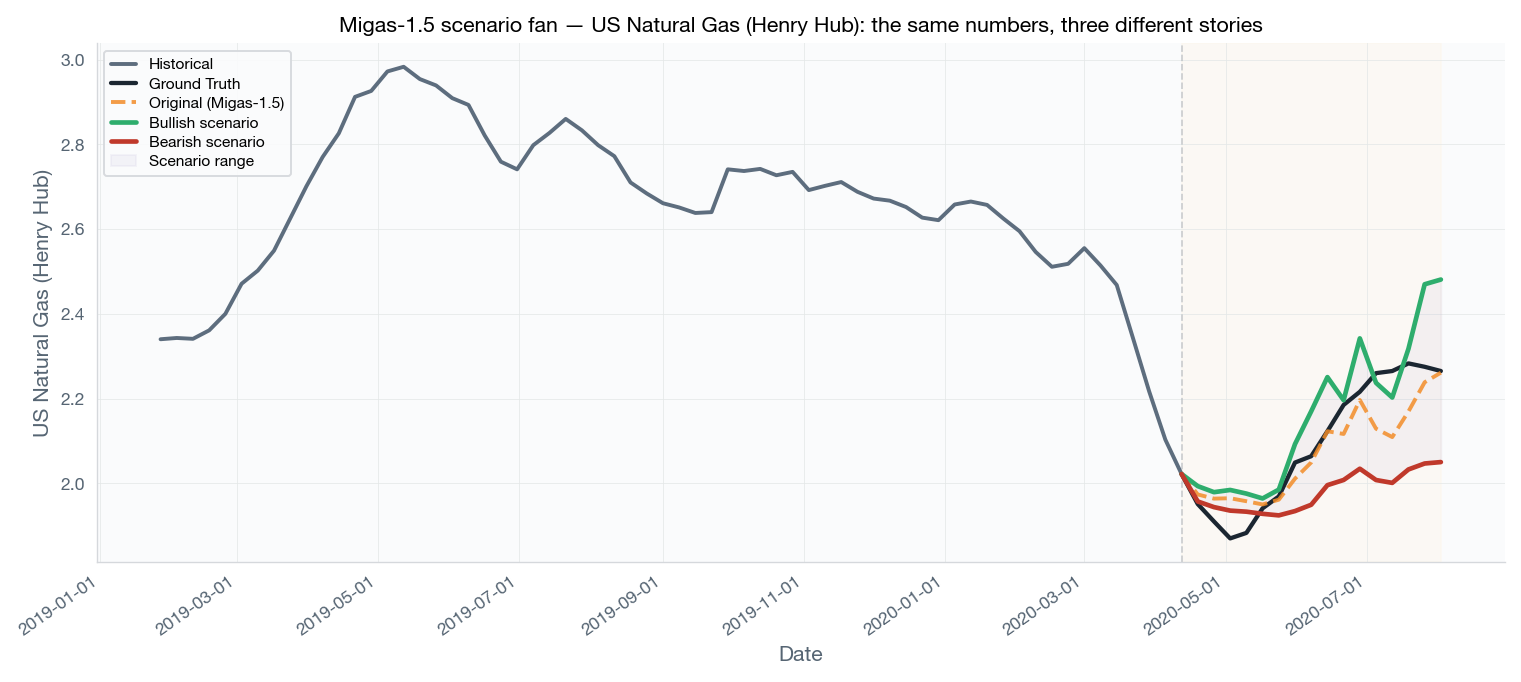

In [29]:
BULLISH_COLOR = "#2EAD6D"
BEARISH_COLOR = "#C0392B"

t_ctx = pd.to_datetime(full["t"].values[:SEQ_LEN])
t_pred = pd.to_datetime(list(full["t"].values[SEQ_LEN - 1 :]))
last_val = float(context_vals[-1])

fig, ax = plt.subplots(figsize=(11, 5))
_draw_forecast_region(
    ax, SEQ_LEN, PRED_LEN, boundary=t_pred[0], boundary_end=t_pred[-1]
)

ax.plot(
    t_ctx,
    context_vals,
    color=COLORS["historical"],
    lw=2.0,
    label="Historical",
    solid_capstyle="round",
)
ax.plot(
    t_pred,
    np.concatenate([[last_val], gt_vals]),
    color=COLORS["ground_truth"],
    lw=2.2,
    label="Ground Truth",
    solid_capstyle="round",
)
ax.plot(
    t_pred,
    np.concatenate([[last_val], migas_fc]),
    color=COLORS["Migas-1.5"],
    lw=2.0,
    ls="--",
    alpha=0.85,
    label="Original (Migas-1.5)",
    solid_capstyle="round",
)
ax.plot(
    t_pred,
    np.concatenate([[last_val], bullish_fc]),
    color=BULLISH_COLOR,
    lw=2.4,
    label="Bullish scenario",
    solid_capstyle="round",
)
ax.plot(
    t_pred,
    np.concatenate([[last_val], bearish_fc]),
    color=BEARISH_COLOR,
    lw=2.4,
    label="Bearish scenario",
    solid_capstyle="round",
)
ax.fill_between(
    t_pred,
    np.concatenate([[last_val], bearish_fc]),
    np.concatenate([[last_val], bullish_fc]),
    alpha=0.08,
    color="#9B8EC4",
    label="Scenario range",
)

format_date_axis(ax)
ax.set_xlabel("Date", color="#566573")
ax.set_ylabel(SERIES_NAME, color="#566573")
ax.set_title(
    f"Migas-1.5 scenario fan — {SERIES_NAME}: the same numbers, three different stories",
    fontsize=11,
    fontweight=600,
)
ax.legend(fontsize=8, handlelength=1.6, labelspacing=0.35, borderpad=0.45)
fig.tight_layout(pad=1.2)
plt.show()

## What's next

- **Try your own data** — point `DATA_PATH` at any CSV with `t`, `y_t`, `split` columns.
- **Generate a fresh summary** — set your API key and re-run Section 3 for a summary
  grounded in real recent context.
- **Batch evaluation** — see [Backtest and Metrics](migas-1.5-backtest-and-metrics.ipynb)
  for rolling-window evaluation with ground truth.